Base Parameter values:
epsilon = 0.0
M = 1.0
g = 3.0
a = 3.4
L = R for paramater variations

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
from scipy.integrate import odeint
import random
from scipy.signal import find_peaks

In [2]:
def dELdt(EL, ER, HL, L_input, params):
    M = params['M']
    a = params['a']
    g = params['g']
    epsilon = params['epsilon']
    tau = params["tau"]
    x = L_input - a*ER + epsilon*EL - g*HL
    return (-EL + M*x) /tau

def dERdt(ER, EL, HR, R_input, params):
    M = params['M']
    a = params['a']
    g = params['g']
    epsilon = params['epsilon']
    tau = params["tau"]
    x = R_input - a*EL + epsilon*ER - g*HR
    return (-ER + M*x) / tau

def dHLdt(HL, EL, params):
    tau_h = params['tau_h']
    return (-HL + EL) / tau_h

def dHRdt(HR, ER, params):
    tau_h = params['tau_h']
    return (-HR + ER) / tau_h

In [3]:
def dXdt(X, t, L_input=1.0, R_input=0.86):
    tau = 15.0
    tau_H = 996.0
    M = 1.0
    a = 3.4
    epsilon = 0.0
    g = 3.0

    EL, ER, HL, HR = X

    dEL = (-EL + M * np.maximum(L_input - a * ER + epsilon * EL - g * HL, 0)) / tau
    dER = (-ER + M * np.maximum(R_input - a * EL + epsilon * ER - g * HR, 0)) / tau
    dHL = (-HL + EL) / tau_H
    dHR = (-HR + ER) / tau_H

    return [dEL, dER, dHL, dHR]

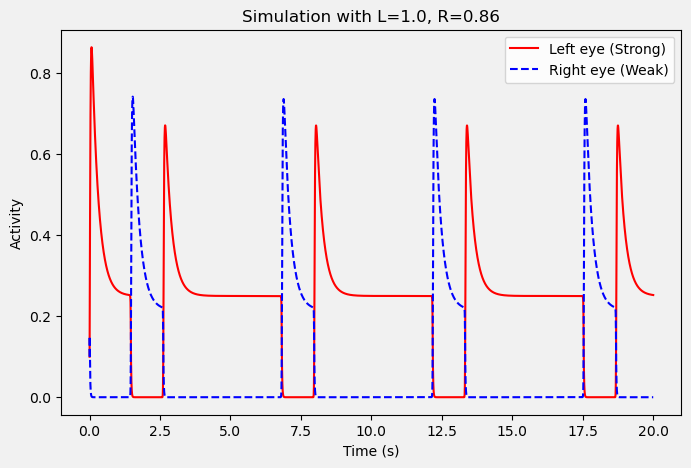

In [4]:
# figure 2
# Initial conditions and time vector
X0 = [0.1, 0.1, 0.0, 0.0]
t = np.linspace(0, 20000, 5001)

X = odeint(dXdt, X0, t)
EL, ER, HL, HR = X.T

fig = plt.figure(figsize=(8, 5))
fig.patch.set_facecolor('#f1f1f1')
plt.gca().set_facecolor('#f1f1f1')
plt.plot(t/1000, EL, 'r-', label='Left eye (Strong)') # Divided by 1000 for seconds
plt.plot(t/1000, ER, 'b--', label='Right eye (Weak)')
plt.title(f"Simulation with L={1.0}, R={0.86}")
plt.xlabel('Time (s)')
plt.ylabel('Activity')
plt.legend()
plt.show()

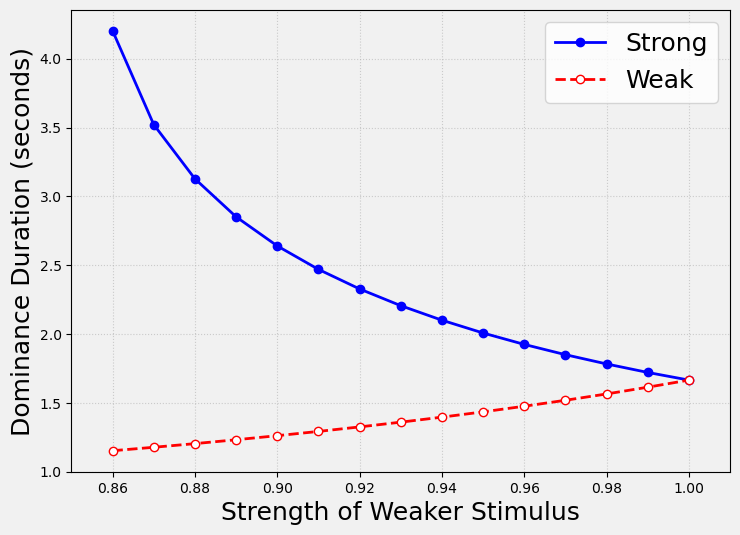

In [5]:
# figure 3
R_strengths = np.linspace(0.86, 1.0, 15) 
L_strength = 1.0

avg_durations_strong = [] # Left eye -Strong
avg_durations_weak = []   # Right eye - weak

t = np.linspace(0, 100000, 100000) # 100 seconds
X0 = [0.11, 0.1, 0.0, 0.0] # asymmetric initial conditions

for R_val in R_strengths:
    X = odeint(dXdt, X0, t, args=(L_strength, R_val))
    X0_new = X[-1,:] # last value
    X = odeint(dXdt, X0_new, t, args=(L_strength, R_val))
    EL = X[:, 0]
    ER = X[:, 1]
    peaks_L, _ = find_peaks(EL, height=0.1)
    peaks_R, _ = find_peaks(ER, height=0.1)

    events = [(i, 'L') for i in peaks_L] + [(i, 'R') for i in peaks_R]
    events.sort(key=lambda x: x[0]) # Sort by time
    
    durations_L = []
    durations_R = []
    
    #find alternating L- R - L patterns
    for k in range(len(events) - 1):
        idx_curr, eye_curr = events[k]
        idx_next, eye_next = events[k+1]
        dt_seconds = (t[idx_next] - t[idx_curr]) / 1000.0
        
        if eye_curr == 'L' and eye_next == 'R':
            # Time from L peak to R peak
            durations_L.append(dt_seconds)
        elif eye_curr == 'R' and eye_next == 'L':
            # Time from R peak to L peak
            durations_R.append(dt_seconds)
            
    if durations_L:
        avg_durations_strong.append(np.mean(durations_L))
    else:
        avg_durations_strong.append(np.nan)
        
    if durations_R:
        avg_durations_weak.append(np.mean(durations_R))
    else:
        avg_durations_weak.append(np.nan)


fig = plt.figure(figsize=(8.5, 6))
fig.patch.set_facecolor('#f1f1f1')
plt.gca().set_facecolor('#f1f1f1')
plt.plot(R_strengths, avg_durations_strong, 'o-', color='blue', label='Strong', linewidth=2)
plt.plot(R_strengths, avg_durations_weak, 'o--', color='red', label='Weak', mfc='white', linewidth=2)
plt.xlabel('Strength of Weaker Stimulus', fontsize=18)
plt.ylabel('Dominance Duration (seconds)', fontsize=18)
plt.legend(prop={'size': 18,})
plt.grid(True, linestyle=':', alpha=0.6)
plt.xlim(0.85, 1.01)
plt.show()

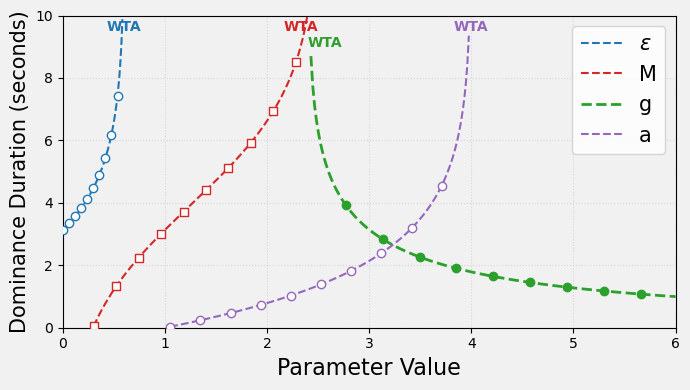

In [6]:
#Fig 5 - time course for symmetric input and asymmetric initial conditions

def theoretical_duration(params, L=1.0, R=1.0):
    tau_H = 1.95 
    M = params['M']
    g = params['g']
    eps = params['epsilon']
    a = params['a']
    

    # Eq 8, solving for denominator tending to 0
    denom = (1/M) + g - eps - (a * (L/R))
    
    with np.errstate(divide='ignore', invalid='ignore'):
        arg = g / denom
        T = tau_H * np.log(arg)
        # Filter out impossible regions (WTA or no oscillation)
        T = np.where((denom <= 0) | (arg <= 1.0), np.nan, T)
        
    return T

# base parameters
base = {'M': 1.0, 'g': 3.0, 'epsilon': 0.0, 'a': 3.4}


#e
eps_limit = (1/base['M']) + base['g'] - base['a']
eps_vals = np.linspace(0, eps_limit - 0.01, 200)
T_eps = theoretical_duration({'M': 1.0, 'g': 3.0, 'epsilon': eps_vals, 'a': 3.4})

# M
M_limit = 1.0 / (base['a'] - base['g'] + base['epsilon'])
M_vals = np.linspace(0.3, M_limit - 0.01, 200)
T_M = theoretical_duration({'M': M_vals, 'g': 3.0, 'epsilon': 0.0, 'a': 3.4})

# g
g_limit = base['a'] + base['epsilon'] - (1/base['M'])
g_vals = np.linspace(g_limit + 0.01, 6.0, 200)
T_g = theoretical_duration({'M': 1.0, 'g': g_vals, 'epsilon': 0.0, 'a': 3.4})

#a
a_limit = (1/base['M']) + base['g'] - base['epsilon']
a_vals = np.linspace(1.05, a_limit - 0.01, 200)
T_a = theoretical_duration({'M': 1.0, 'g': 3.0, 'epsilon': 0.0, 'a': a_vals})


def ten_s_plot(T): 
    return np.where(T > 10, np.nan, T) # cuts after 10 seconds

fig = plt.figure(figsize=(7, 4))
fig.patch.set_facecolor('#f1f1f1')
plt.gca().set_facecolor('#f1f1f1')

c_eps = 'tab:blue'
c_M = 'tab:red'
c_g = 'tab:green'
c_a = 'tab:purple'

plt.plot(eps_vals, ten_s_plot(T_eps), '--', color=c_eps, label=r'$\epsilon$')
plt.scatter(eps_vals[::20], ten_s_plot(T_eps)[::20], color='white', edgecolors=c_eps, zorder=3)
plt.text(eps_limit, 9.5, "WTA", color=c_eps, fontweight='bold', ha='center')

plt.plot(M_vals, ten_s_plot(T_M), '--', color=c_M, label='M')
plt.scatter(M_vals[::20], ten_s_plot(T_M)[::20], marker='s', color='white', edgecolors=c_M, zorder=3)
plt.text(M_limit, 9.5, "WTA", color=c_M, fontweight='bold', ha='right')

plt.plot(g_vals, ten_s_plot(T_g), '--', color=c_g, linewidth=2, label='g')
plt.scatter(g_vals[::20], ten_s_plot(T_g)[::20], color=c_g, edgecolors=c_g, zorder=3)
plt.text(g_limit, 9.0, "WTA", color=c_g, fontweight='bold', ha='left')

plt.plot(a_vals, ten_s_plot(T_a), '--', color=c_a, label='a')
plt.scatter(a_vals[::20], ten_s_plot(T_a)[::20], color='white', edgecolors=c_a, zorder=3)
plt.text(a_limit, 9.5, "WTA", color=c_a, fontweight='bold', ha='center')

plt.xlabel('Parameter Value', fontsize=16)
plt.ylabel('Dominance Duration (seconds)', fontsize=15)
plt.ylim(0, 10)
plt.xlim(0, 6)
plt.legend(prop={'size': 15})
plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

/var/folders/qq/plc0t9_900x48dmp2lkz0k3m0000gn/T/ipykernel_27475/3177482261.py:51: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(E_grid_L, E_grid_R, dEL, levels=[0], colors='blue', linewidths=2, label='EL Nullcline')
/var/folders/qq/plc0t9_900x48dmp2lkz0k3m0000gn/T/ipykernel_27475/3177482261.py:52: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(E_grid_L, E_grid_R, dER, levels=[0], colors='red', linewidths=2, label='ER Nullcline')


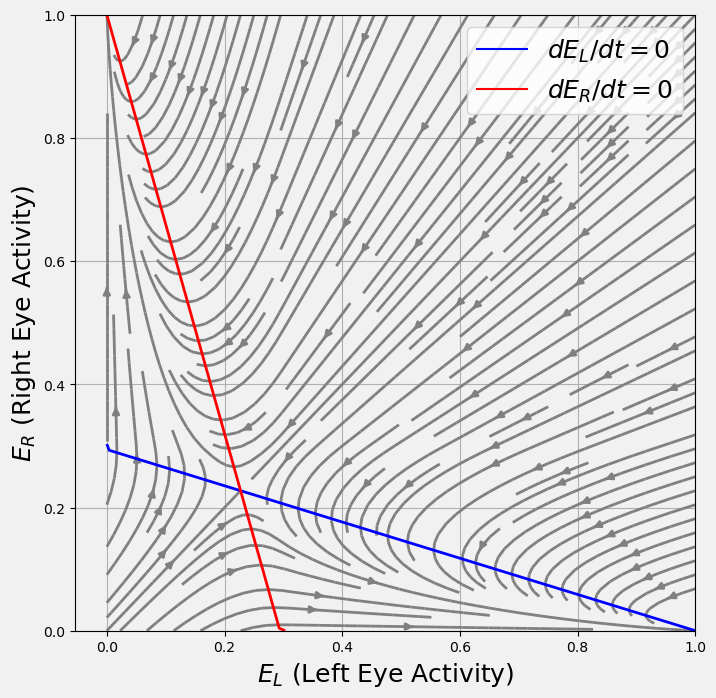

In [7]:
# Phase plane when H is treated as a constant - tau_h >> tau

M = 1.0
a = 3.4
epsilon = 0.0
g = 3.0
tau = 15.0
L = 1.0
R = 1.0

J_11 = (-1 + M * epsilon) / tau
J_12 = (-M * a) / tau
J_21 = (-M * a) / tau
J_22 = (-1 + M * epsilon) / tau

jacobian = np.array([[J_11, J_12],
                     [J_21, J_22]])

# Calculate Eigenvalues
eigenvalues = np.linalg.eigvals(jacobian)
max_eigenvalue = np.max(np.real(eigenvalues))

HL_fixed = 0.0
HR_fixed = 0.0

# Define range for EL and ER
E_range = np.linspace(0, 1.0, 100)
E_grid_L, E_grid_R = np.meshgrid(E_range, E_range)

# Calculate Nullclines (where dE/dt = 0)

nc_L_y = (M*(L - g*HL_fixed) - E_range*(1 - M*epsilon)) / (M*a)

# Nullcline for ER: ER = M * [R - a*EL + eps*ER - g*HR]+

dEL = (-E_grid_L + M * np.maximum(L - a * E_grid_R + epsilon * E_grid_L - g * HL_fixed, 0)) / tau
dER = (-E_grid_R + M * np.maximum(R - a * E_grid_L + epsilon * E_grid_R - g * HR_fixed, 0)) / tau

# Plot
fig = plt.figure(figsize=(8, 8))
fig.patch.set_facecolor('#f1f1f1')
plt.gca().set_facecolor('#f1f1f1')
# plt.title(f"Fast System Phase Plane)", fontsize=20)
plt.xlabel("$E_L$ (Left Eye Activity)", fontsize=18)
plt.ylabel("$E_R$ (Right Eye Activity)", fontsize=18)

# Streamplot to show flow
plt.streamplot(E_range, E_range, dEL, dER, color='gray', linewidth=2, density=1.5)

# Plot Nullclines (approximate via contour)
plt.contour(E_grid_L, E_grid_R, dEL, levels=[0], colors='blue', linewidths=2, label='EL Nullcline')
plt.contour(E_grid_L, E_grid_R, dER, levels=[0], colors='red', linewidths=2, label='ER Nullcline')

# Add legend (proxy artists)
import matplotlib.lines as mlines
blue_line = mlines.Line2D([], [], color='blue', label='$dE_L/dt = 0$')
red_line = mlines.Line2D([], [], color='red', label='$dE_R/dt = 0$')
plt.legend(handles=[blue_line, red_line], loc='upper right', prop={'size': 18, 'weight': 'bold'})

plt.grid(True)
plt.show()
